<a href="https://colab.research.google.com/github/00-Vinaylohar-00/AI_2026_AI/blob/main/Linear_regression_Health_Insuarance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
path=r'https://raw.githubusercontent.com/hakimyameen/Datasets/refs/heads/main/Health_insurance.csv'
df= pd.read_csv(path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
# cheking the data column which are the objects  or strings
ob_col=df.select_dtypes('object').columns
ob_col

Index(['sex', 'smoker', 'region'], dtype='object')

In [ ]:
#checking the count of the object data is balance or imbalance
df[['smoker']].value_counts()
for i in ob_col:
  print(df[i].value_counts())
  print('--------------')

sex
male      676
female    662
Name: count, dtype: int64
--------------
smoker
no     1064
yes     274
Name: count, dtype: int64
--------------
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
--------------


In [ ]:
# now as machine is not understanding the object so
# we have to convert it to machine language like 0,1 ,
# for that we are using map operation
df['sex']=df['sex'].map({'male':0,'female':1})

In [ ]:
df[:4]

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061


In [ ]:
df['smoker']=df['smoker'].map({'no':0,'yes':1})

In [ ]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
df['region']=df['region'].map({'southeast':0,'southwest':1,'northwest':2,'northeast':3})

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,16884.92400
1,18,0,33.770,1,0,0,1725.55230
2,28,0,33.000,3,0,0,4449.46200
3,33,0,22.705,0,0,2,21984.47061
4,32,0,28.880,0,0,2,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,2,10600.54830
1334,18,1,31.920,0,0,3,2205.98080
1335,18,1,36.850,0,0,0,1629.83350
1336,21,1,25.800,0,0,1,2007.94500


In [ ]:
# now we want input and output separate
x=df.iloc[:,:-1]
x[:2]

,age,sex,bmi,children,smoker,region
0,19,1,27.90,0,1,1
1,18,0,33.77,1,0,0


In [ ]:
y=df['charges']
y[:2]

,charges
0,16884.9240
1,1725.5523


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()
model.fit(x,y)

LinearRegression()

In [ ]:
model.score(x,y)*100

75.08283519755356

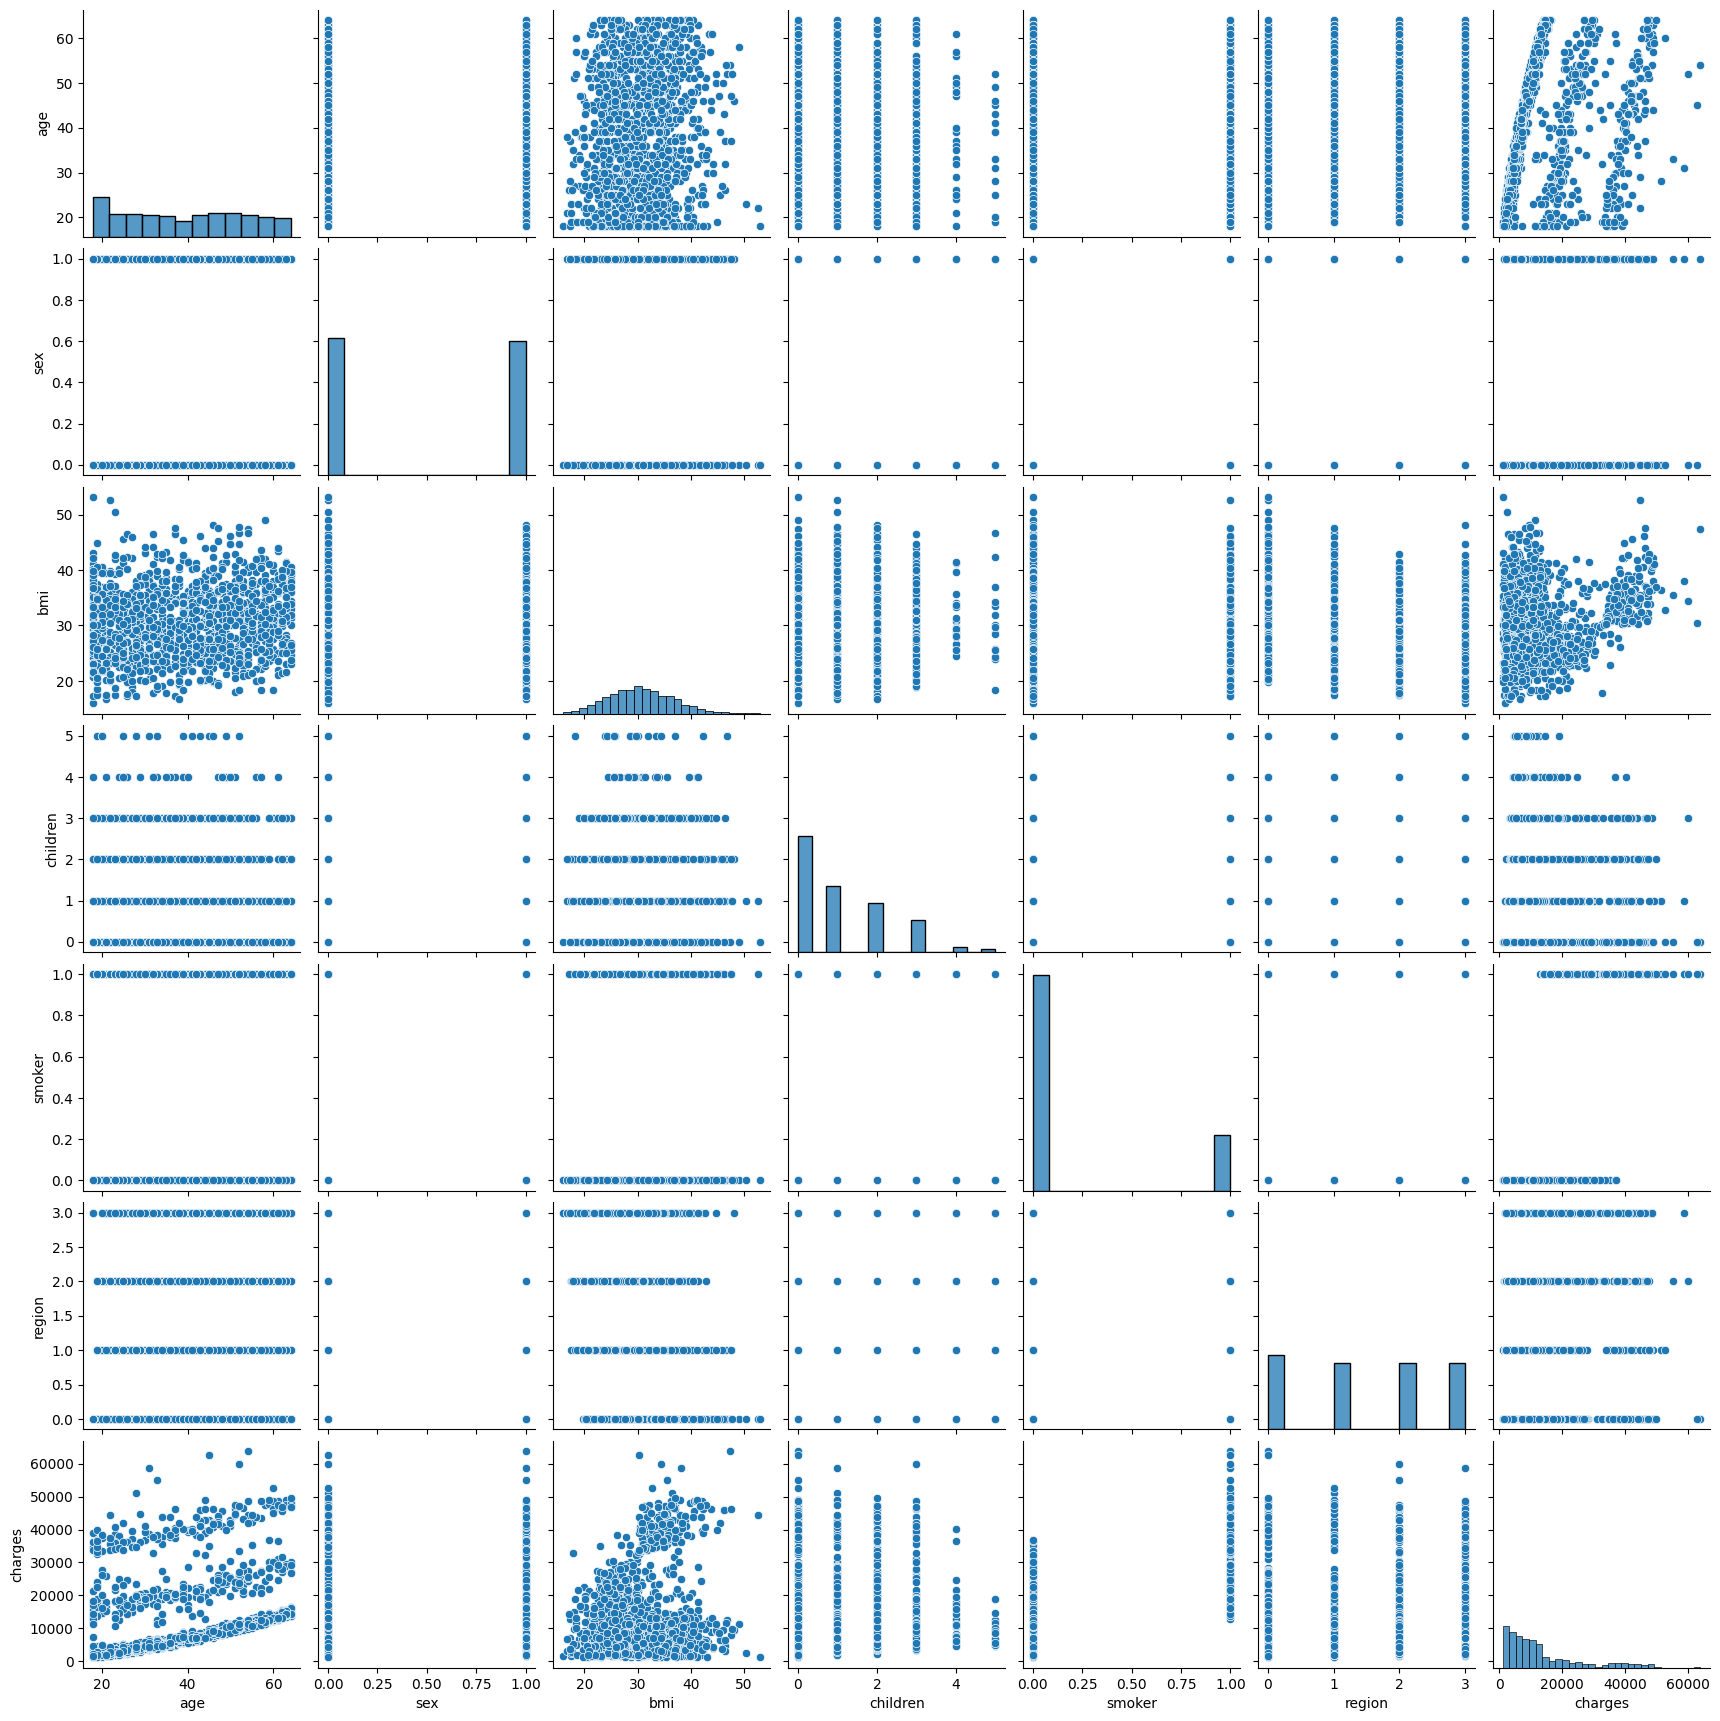

In [ ]:
# as accuracy score came arounf 75 % so we will check some pairplots  to know what is happeining in data
import seaborn as sns
sns.pairplot(df)

In [ ]:
# the data looks very much scteer , not positive, not negative also full scatter
# lets try another powerfull algorithm
from sklearn.tree import DecisionTreeRegressor

In [ ]:
dt=DecisionTreeRegressor()
dt.fit(x,y)
dt.score(x,y)

0.998667156135576

In [ ]:
# now we will deploy the the model we made
# for that we will use serialix=zed model of algorithm
import pickle
pickle.dump(dt,open('model.pkl','wb'))

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR